In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("data/employee_attrition.csv")

In [3]:
print(f"Shape: {df.shape}")
print(f"\n{df.dtypes}")
print(f"\n{df.info()}")
print(f"\n{round(df.describe(), 2)}")

Shape: (2500, 19)

age                            int64
gender                        object
education                     object
department                    object
job_level                     object
years_at_company             float64
years_in_role                float64
num_companies_worked           int64
monthly_income               float64
overtime                      object
work_life_balance            float64
job_satisfaction               int64
relationship_satisfaction      int64
environment_satisfaction     float64
training_last_year           float64
performance_rating             int64
distance_from_home             int64
business_travel               object
attrition                      int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        2500 non-null

In [4]:
quantity = df['attrition'].value_counts()
percent  = df['attrition'].value_counts(normalize=True) * 100
print(f"O lai     {quantity[0]:>5} - ty le {percent[0]:.1f}%")
print(f"Nghi lam  {quantity[1]:>5} - ty le {percent[1]:.1f}%")

print("""
        Nhận xét: Dataset bị imbalanced  (~70/30).
        Phải dùng Recall, F1, ROC-AUC thay vì Accuracy làm metric chính.
""")




O lai      1747 - ty le 69.9%
Nghi lam    753 - ty le 30.1%

        Nhận xét: Dataset bị imbalanced  (~70/30).
        Phải dùng Recall, F1, ROC-AUC thay vì Accuracy làm metric chính.



In [5]:
print("--- Missing Values ---")
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
report = pd.DataFrame({'Count': missing, 'Percent(%)': missing_pct})
print(report[report['Count'] > 0])
print("--- Outliers ---")
numeric_col = df.select_dtypes(['float64', "int64"]).columns
for col in numeric_col:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = (df[col] < lower) | (df[col] > upper)
    
    if outliers.sum() > 0:
        print(f"{col:20}: {outliers.sum()} - range [{lower:.1f}, {upper:.1f}]")

--- Missing Values ---
                          Count  Percent(%)
monthly_income              111        4.44
work_life_balance           124        4.96
environment_satisfaction    112        4.48
training_last_year           72        2.88
--- Outliers ---
age                 : 10 - range [2.5, 78.5]
years_at_company    : 132 - range [-5.8, 12.6]
years_in_role       : 169 - range [-3.5, 7.7]
monthly_income      : 50 - range [2400.0, 12000.0]
performance_rating  : 67 - range [1.5, 5.5]


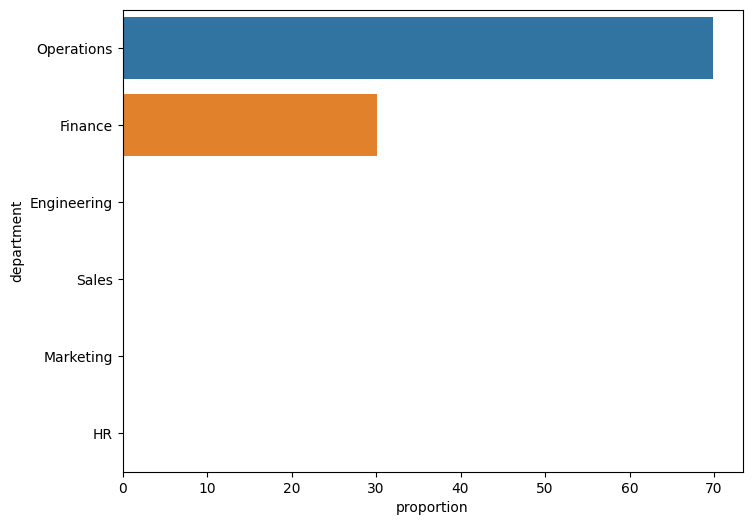

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data = df,
    x = percent,
    y = 'department',
    hue = 'department'
)

plt.show()

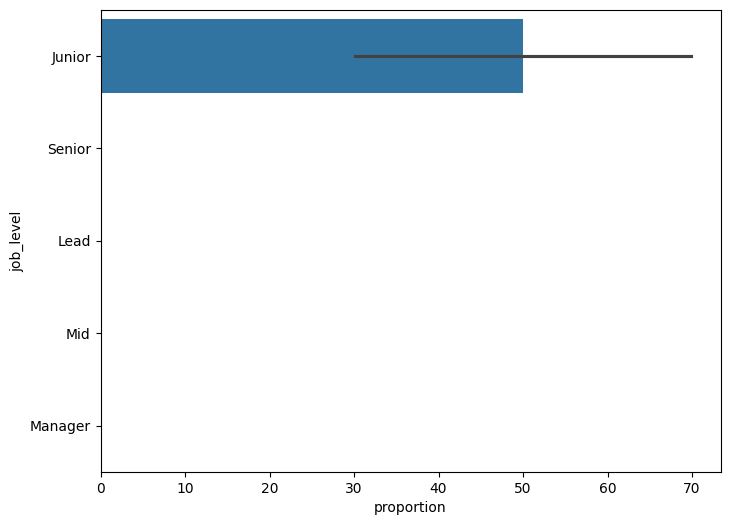

In [7]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=df,
    x = percent,
    y = 'job_level'
)

plt.show()

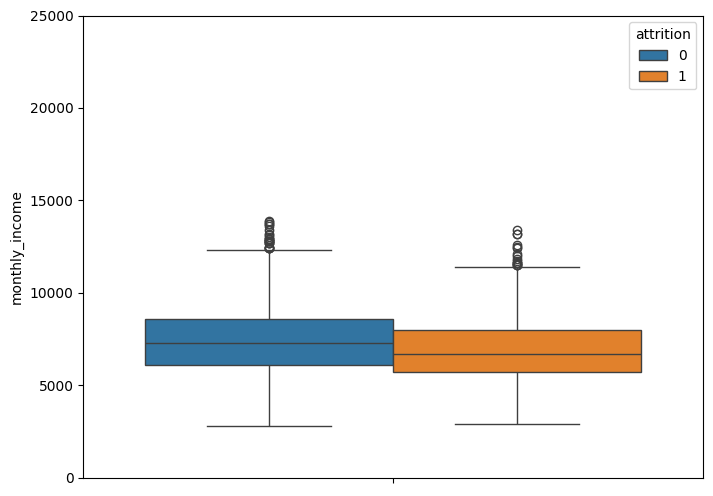

In [8]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='monthly_income', hue='attrition')
plt.ylim(0, 25000) 
plt.show()

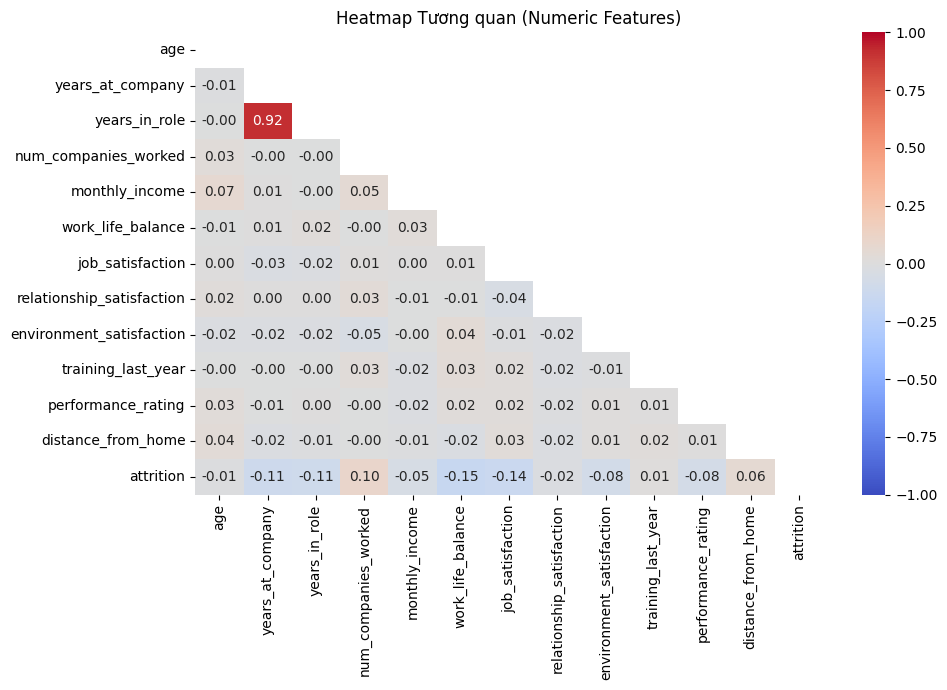

In [9]:
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) 
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, center=0)
plt.title("Heatmap Tương quan (Numeric Features)")
plt.tight_layout()
plt.savefig("output/eda_heatmap.png", dpi=150)
plt.show()

In [10]:
before = len(df)
df = df[(df['age'].isna()) | (df['age'] < 100)]
df = df[(df['monthly_income'].isna()) | (df['monthly_income'] < 50000)]
df = df.reset_index(drop=True)
print(f"Dropped {before - len(df)} outlier rows → còn {len(df)} rows")

Dropped 20 outlier rows → còn 2480 rows


In [11]:
df['monthly_income'] = df['monthly_income'].fillna(
    df.groupby('job_level')['monthly_income'].transform('median')
)

df['work_life_balance'] = df['work_life_balance'].fillna(df['work_life_balance'].median())
df['environment_satisfaction'] = df['environment_satisfaction'].fillna(df['environment_satisfaction'].median())
df['training_last_year'] = df['training_last_year'].fillna(0)

df['role_tenure_ratio'] = df['years_in_role'] / (df['years_at_company'] + 1)

level_median = df.groupby('job_level')['monthly_income'].transform('median')
df['income_vs_level'] = df['monthly_income'] / level_median

df['total_satisfaction'] = (
    df['job_satisfaction'] +
    df['relationship_satisfaction'] +
    df['environment_satisfaction'] +
    df['work_life_balance']
)

In [12]:
encode_col =  ['gender', 'education', 'department', 'job_level', 'overtime', 'business_travel']
df_final = pd.get_dummies(df, columns=encode_col, drop_first=True, dtype=int)


print(f"Shape sau encoding: {df_final.shape}")
print(f"Null còn lại: {df_final.isnull().sum().sum()}")

Shape sau encoding: (2480, 32)
Null còn lại: 0


In [13]:
from sklearn.model_selection import train_test_split

X = df_final.drop(columns=['attrition'])
y = df_final['attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")



Train: 1860 | Test: 620


In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

print(f"{'Depth':<8}{'Train Acc':>10}{'Test Acc':>10}{'F1':>8}{'Overfit':>10}")
print("-" * 44)

dt_results = {}
for depth in [3, 5, 7, 10, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_pred = dt.predict(X_train)
    test_pred = dt.predict(X_test)
    test_proba = dt.predict_proba(X_test)[:,1]
    
    result = {
        'train_acc': accuracy_score(y_train, train_pred),
        'test_acc':  accuracy_score(y_test, test_pred),
        'f1':        f1_score(y_test, test_pred),
        'gap': accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred),
        'model':     dt
    }
    
    dt_results[depth] = result
    label = str(depth) if depth else 'None'
    print(f"{label:<8}{result['train_acc']:>10.4f}{result['test_acc']:>10.4f}"
          f"{result['f1']:>8.4f}{result['gap']:>10.4f}")
    

best_depth = max(dt_results, key=lambda d: dt_results[d]['f1'])
best_dt = dt_results[best_depth]['model']
print(f"\nBest DT: max_depth ={best_depth}")
    


Depth    Train Acc  Test Acc      F1   Overfit
--------------------------------------------
3           0.7333    0.7000  0.3162    0.0333
5           0.7694    0.7032  0.3429    0.0661
7           0.8108    0.7016  0.3771    0.1091
10          0.9059    0.6468  0.3761    0.2591
None        1.0000    0.6016  0.3683    0.3984

Best DT: max_depth =7


In [16]:

print(f"{'n_trees':<8}{'Train Acc':>10}{'Test Acc':>10}{'F1':>8}{'AUC':>10}")
print("-" * 44)

rf_results = {}
for n in [10, 50, 100, 200, 500]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    train_pred = rf.predict(X_train)
    test_pred = rf.predict(X_test)
    test_proba = rf.predict_proba(X_test)[:,1]
    
    result = {
        'train_acc': accuracy_score(y_train, train_pred),
        'test_acc':  accuracy_score(y_test, test_pred),
        'f1':        f1_score(y_test, test_pred),
        'auc':       roc_auc_score(y_test, test_proba),
        'model':     rf
    }
    
    rf_results[n] = result
    print(f"{n:<10}{result['train_acc']:>10.4f}{result['test_acc']:>10.4f}"
          f"{result['f1']:>8.4f}{result['auc']:>8.4f}")
    
best_n_trees = max(rf_results, key=lambda d: rf_results[d]['f1'])
best_rf = rf_results[best_n_trees]['model']
print(f"\nBest RF: n_trees  ={best_n_trees}")
    

n_trees  Train Acc  Test Acc      F1       AUC
--------------------------------------------
10            0.9812    0.6968  0.3333  0.6389
50            0.9995    0.7161  0.3714  0.6983
100           1.0000    0.7210  0.3887  0.6976
200           1.0000    0.7242  0.3736  0.7116
500           1.0000    0.7339  0.3911  0.7158

Best RF: n_trees  =500


In [26]:
def metrics_row(name, model, X, y):
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]
    return {
        'Model': name,
        'Accuracy':  accuracy_score(y, pred),
        'Precision': precision_score(y, pred),
        'Recall':    recall_score(y, pred),
        'F1':        f1_score(y, pred),
        'ROC-AUC':   roc_auc_score(y, prob),
    }

rows = [
    metrics_row(f"Decision Tree (depth={best_depth})", best_dt, X_test, y_test),
    metrics_row("Random Forest (100 trees)", best_rf, X_test, y_test),
]
results_df = pd.DataFrame(rows).set_index('Model')
print(results_df.round(4))



                           Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                                  
Decision Tree (depth=7)      0.7016     0.5091  0.2995  0.3771   0.6666
Random Forest (100 trees)    0.7339     0.6310  0.2834  0.3911   0.7158
